In [ ]:
# ======================================================
# AGENTIC RAG SYSTEM (Track A Compliant with Pathway)
# ======================================================

In [ ]:
!pip install -q "numpy>=2.0.0" "pandas>=2.2.0" pathway transformers accelerate bitsandbytes torch torchvision

In [ ]:
!pip uninstall -y numpy scipy scikit-learn
!pip install -q --no-cache-dir \
  numpy==1.23.5 \
  scipy==1.11.4 \
  scikit-learn==1.3.2

In [ ]:
!pip install -q --upgrade numpy==1.26.4
!pip uninstall -y tensorflow tensorflow-cpu jax jaxlib flax

In [1]:
import os

os.environ["TRANSFORMERS_NO_TF"] = "1"
os.environ["TRANSFORMERS_NO_FLAX"] = "1"
os.environ["TRANSFORMERS_NO_JAX"] = "1"

In [2]:
# ======================================================
# CELL 1: IMPORT ALL DEPENDENCIES
# ======================================================
import os
import sys
import pickle
import json
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
import pathway as pw
from tqdm import tqdm
from typing import List, Dict
from enum import Enum
from datetime import datetime
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, classification_report
from transformers import AutoTokenizer, AutoModel, AutoModelForCausalLM, AutoConfig, BitsAndBytesConfig

print("✓ All dependencies installed")
print(f"  Torch: {torch.__version__}")
print(f"  Pathway: {pw.__version__}")
print(f"  Pandas: {pd.__version__}")

✓ All dependencies installed
  Torch: 2.6.0+cu124
  Pathway: 0.27.1
  Pandas: 2.2.3


In [3]:
# ======================================================
# CELL 2: CONFIGURATION
# ======================================================

# UPDATE THESE PATHS TO YOUR KAGGLE INPUTS
CASTAWAYS_PKL = "/kaggle/input/kdsh26-in-search-of-the-castaways-processeddataset/castaways_chunks.pkl"
MONTECRISTO_PKL = "/kaggle/input/kdsh26-the-count-of-monte-cristo-processeddataset/montecristo_chunks.pkl"
CASTAWAYS_EMB = "/kaggle/input/kdsh26-in-search-of-the-castaways-processeddataset/castaways_embeddings_qwen.pkl"
MONTECRISTO_EMB = "/kaggle/input/kdsh26-the-count-of-monte-cristo-processeddataset/montecristo_embeddings_qwen.pkl"

TEST_CSV = "/kaggle/input/kharagpur-data-science-hackathon-kdsh-2026-dataset/test.csv"
TRAIN_CSV = "/kaggle/input/kharagpur-data-science-hackathon-kdsh-2026-dataset/train.csv"

# Model IDs
EMBED_MODEL_ID = "Alibaba-NLP/gte-Qwen2-7B-instruct"
LLM_MODEL_ID = "Qwen/Qwen2.5-14B-Instruct"

# Output files
SUBMISSION_FILE = "submission_agentic_rag.csv"
VALIDATION_FILE = "validation_results_agentic_rag.csv"

print("Configuration loaded:")
print(f"  Embedding Model: {EMBED_MODEL_ID}")
print(f"  LLM Model: {LLM_MODEL_ID}")


Configuration loaded:
  Embedding Model: Alibaba-NLP/gte-Qwen2-7B-instruct
  LLM Model: Qwen/Qwen2.5-14B-Instruct


In [4]:
# ======================================================
# CELL 3: HELPER FUNCTIONS
# ======================================================

def last_token_pool(last_hidden_states, attention_mask):
    """Extract last token for pooling"""
    left_padding = (attention_mask[:, -1].sum() == attention_mask.shape[0])
    if left_padding:
        return last_hidden_states[:, -1]
    else:
        sequence_lengths = attention_mask.sum(dim=1) - 1
        batch_size = last_hidden_states.shape[0]
        return last_hidden_states[torch.arange(batch_size, device=last_hidden_states.device), sequence_lengths]

print("✓ Helper functions defined")


✓ Helper functions defined


In [5]:
# ======================================================
# CELL 4: LOAD EMBEDDING & LLM MODELS
# ======================================================

print("Loading Embedding Model...")
emb_config = AutoConfig.from_pretrained(EMBED_MODEL_ID, trust_remote_code=True)
emb_config.use_cache = False
embed_tokenizer = AutoTokenizer.from_pretrained(EMBED_MODEL_ID, trust_remote_code=True)
embed_model = AutoModel.from_pretrained(
    EMBED_MODEL_ID, 
    config=emb_config, 
    trust_remote_code=True, 
    torch_dtype=torch.float16
).to("cuda")
embed_model.eval()
print("✓ Embedding Model loaded")

print("\nLoading Judge LLM...")
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)
llm_tokenizer = AutoTokenizer.from_pretrained(LLM_MODEL_ID, trust_remote_code=True)
llm_model = AutoModelForCausalLM.from_pretrained(
    LLM_MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True
)
print("✓ LLM Model loaded")


Loading Embedding Model...


/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

Loading checkpoint shards:   0%|          | 0/7 [00:00<?, ?it/s]

✓ Embedding Model loaded

Loading Judge LLM...


Loading checkpoint shards:   0%|          | 0/8 [00:00<?, ?it/s]

✓ LLM Model loaded


In [16]:
# # ======================================================
# # CELL X: CONVERT PKL → PARQUET + NPY (RUN ONCE)
# # ======================================================

# CASTAWAYS_PKL = "/kaggle/input/kdsh26-in-search-of-the-castaways-processeddataset/castaways_chunks.pkl"
# CASTAWAYS_EMB_PKL = "/kaggle/input/kdsh26-in-search-of-the-castaways-processeddataset/castaways_embeddings_qwen.pkl"

# MONTECRISTO_PKL = "/kaggle/input/kdsh26-the-count-of-monte-cristo-processeddataset/montecristo_chunks.pkl"
# MONTECRISTO_EMB_PKL = "/kaggle/input/kdsh26-the-count-of-monte-cristo-processeddataset/montecristo_embeddings_qwen.pkl"

# print("Loading PKL files...")

# # ---- Castaways ----
# df_cast = pd.read_pickle(CASTAWAYS_PKL)
# with open(CASTAWAYS_EMB_PKL, "rb") as f:
#     vec_cast = pickle.load(f)

# # ---- Monte Cristo ----
# df_monte = pd.read_pickle(MONTECRISTO_PKL)
# with open(MONTECRISTO_EMB_PKL, "rb") as f:
#     vec_monte = pickle.load(f)

# print("Saving safe formats...")

# df_cast.to_parquet("castaways.parquet")
# np.save("castaways_emb.npy", vec_cast)

# df_monte.to_parquet("montecristo.parquet")
# np.save("montecristo_emb.npy", vec_monte)

# print("✓ Conversion complete")


In [18]:
# ======================================================
# CELL 4.5: NUMPY COMPATIBILITY PATCH (RUN BEFORE CELL 5)
# ======================================================

import sys
import numpy

print("Applying NumPy compatibility patches...")

# Patch 1: Handle numpy._core references
try:
    from numpy import _core
    if not hasattr(numpy, 'core'):
        sys.modules['numpy.core'] = _core
        numpy.core = _core
    
    sys.modules['numpy.core.multiarray'] = _core.multiarray
    sys.modules['numpy.core.numeric'] = _core.numeric
    print("✓ NumPy._core patches applied")
except Exception as e:
    print(f"⚠ Could not apply _core patches: {e}")

# Patch 2: Alternative NumPy version handling
try:
    import numpy.core.multiarray as ma
    sys.modules['numpy._core.multiarray'] = ma
    sys.modules['numpy._core.numeric'] = numpy.core.numeric
    print("✓ NumPy.core reverse mapping applied")
except:
    pass

print("✓ NumPy compatibility patches complete")


Applying NumPy compatibility patches...
⚠ Could not apply _core patches: module 'numpy._core' has no attribute 'numeric'
✓ NumPy.core reverse mapping applied
✓ NumPy compatibility patches complete


In [30]:
# ======================================================
# CELL 5 (FIXED): LOAD PROCESSED CHUNKS & EMBEDDINGS
# ======================================================

import warnings
warnings.filterwarnings('ignore')

print("Loading processed data...\n")

def safe_pickle_load(filepath, description):
    """Safely load pickle files with error handling"""
    try:
        print(f"  Attempting to load: {description}...", end=" ")
        data = pd.read_pickle(filepath)
        print(f"✓ Success ({len(data)} rows)")
        return data
    except Exception as e:
        print(f"✗ Error: {e}")
        return None

# Load Castaways
print("Loading Castaways data:")
df_cast = safe_pickle_load(CASTAWAYS_PKL, "Castaways chunks")

print("Loading Castaways embeddings:")
try:
    print("  Attempting to load embeddings...", end=" ")
    with open(CASTAWAYS_EMB, 'rb') as f:
        vec_cast_list = pickle.load(f)
    # Convert to float16 to match embedding model dtype
    vec_cast = np.array(vec_cast_list, dtype=np.float16)
    print(f"✓ Success ({len(vec_cast)} vectors, float16)")
except Exception as e:
    print(f"✗ Error: {e}")
    vec_cast = np.zeros((len(df_cast), 3584), dtype=np.float16)
    print(f"  Created placeholder ({len(vec_cast)} vectors, float16)")

print()

# Load Monte Cristo
print("Loading Monte Cristo data:")
df_monte = safe_pickle_load(MONTECRISTO_PKL, "Monte Cristo chunks")

print("Loading Monte Cristo embeddings:")
try:
    print("  Attempting to load embeddings...", end=" ")
    with open(MONTECRISTO_EMB, 'rb') as f:
        vec_monte_list = pickle.load(f)
    # Convert to float16 to match embedding model dtype
    vec_monte = np.array(vec_monte_list, dtype=np.float16)
    print(f"✓ Success ({len(vec_monte)} vectors, float16)")
except Exception as e:
    print(f"✗ Error: {e}")
    vec_monte = np.zeros((len(df_monte), 3584), dtype=np.float16)
    print(f"  Created placeholder ({len(vec_monte)} vectors, float16)")

print()

# Validation
print("Data Validation:")
print(f"  ✓ Castaways: {len(df_cast)} chunks × {vec_cast.shape[1]} dimensions")
print(f"    └─ dtype: {vec_cast.dtype}")
print(f"  ✓ Monte Cristo: {len(df_monte)} chunks × {vec_monte.shape[1]} dimensions")
print(f"    └─ dtype: {vec_monte.dtype}")

# Create book data dictionary with GPU tensors (float16)
print("\nCreating GPU tensors...")
try:
    BOOK_DATA = {
        "In Search of the Castaways": (
            df_cast, 
            torch.from_numpy(vec_cast).cuda()
        ),
        "The Count of Monte Cristo": (
            df_monte, 
            torch.from_numpy(vec_monte).cuda()
        )
    }
    
    print("✓ GPU tensors created successfully")
    print(f"  Device: cuda")
    print(f"  Dtype: float16 (matches embedding model)")
    print()
    
except RuntimeError as e:
    print(f"⚠ CUDA error, falling back to CPU: {e}")
    BOOK_DATA = {
        "In Search of the Castaways": (
            df_cast, 
            torch.from_numpy(vec_cast)
        ),
        "The Count of Monte Cristo": (
            df_monte, 
            torch.from_numpy(vec_monte)
        )
    }
    print("✓ CPU tensors created")
    print(f"  Device: cpu")
    print(f"  Dtype: float16")
    print()
    
except Exception as e:
    print(f"❌ Error creating tensors: {e}")
    print("Creating fallback structure...")
    BOOK_DATA = {
        "In Search of the Castaways": (df_cast, None),
        "The Count of Monte Cristo": (df_monte, None)
    }

print("="*80)
print("✓ ALL DATA LOADED SUCCESSFULLY")
print("="*80)
print(f"\nSummary:")
print(f"  Total chunks: {len(df_cast) + len(df_monte)}")
print(f"  Books: {list(BOOK_DATA.keys())}")
print(f"  Embedding dimension: 3584")
print(f"  Data type: float16")
print(f"\nDtype Compatibility Check:")
for book_name, (df, emb_tensor) in BOOK_DATA.items():
    if emb_tensor is not None:
        print(f"  {book_name}: {emb_tensor.dtype} ✓")
    else:
        print(f"  {book_name}: ✗ (embedding tensor is None)")

print("\n" + "="*80)
print("READY FOR INFERENCE")
print("="*80)


Loading processed data...

Loading Castaways data:
  Attempting to load: Castaways chunks... ✓ Success (299 rows)
Loading Castaways embeddings:
  Attempting to load embeddings... ✓ Success (299 vectors, float16)

Loading Monte Cristo data:
  Attempting to load: Monte Cristo chunks... ✓ Success (1024 rows)
Loading Monte Cristo embeddings:
  Attempting to load embeddings... ✓ Success (1024 vectors, float16)

Data Validation:
  ✓ Castaways: 299 chunks × 3584 dimensions
    └─ dtype: float16
  ✓ Monte Cristo: 1024 chunks × 3584 dimensions
    └─ dtype: float16

Creating GPU tensors...
✓ GPU tensors created successfully
  Device: cuda
  Dtype: float16 (matches embedding model)

✓ ALL DATA LOADED SUCCESSFULLY

Summary:
  Total chunks: 1323
  Books: ['In Search of the Castaways', 'The Count of Monte Cristo']
  Embedding dimension: 3584
  Data type: float16

Dtype Compatibility Check:
  In Search of the Castaways: torch.float16 ✓
  The Count of Monte Cristo: torch.float16 ✓

READY FOR INFERENC

In [31]:
# ========== DEFINE AGENT TOOLS ==========
class AgentAction(Enum):
    RETRIEVE = "retrieve"
    EVALUATE = "evaluate"
    REFINE_QUERY = "refine_query"
    FINAL_DECIDE = "final_decide"
    STOP = "stop"

class AgentTool:
    """Base class for agent tools"""
    def __init__(self, name: str, description: str):
        self.name = name
        self.description = description
    
    def execute(self, **kwargs):
        raise NotImplementedError

In [32]:
# ========== TOOL 1: SEMANTIC RETRIEVAL TOOL ==========
class SemanticRetrievalTool(AgentTool):
    """Tool for semantic search and document retrieval"""
    
    def __init__(self, book_data, embed_model, embed_tokenizer, k=5):
        super().__init__(
            name="semantic_retrieval",
            description="Retrieve documents similar to query using semantic search"
        )
        self.book_data = book_data
        self.embed_model = embed_model
        self.embed_tokenizer = embed_tokenizer
        self.k = k
        self.last_retrieval_confidence = 0.0
    
    def encode_query(self, query: str) -> torch.Tensor:
        """Encode query to embedding"""
        instruction = f"Instruct: Given a user query, retrieve relevant passages from the novel.\nQuery: {query}"
        inputs = self.embed_tokenizer(
            [instruction], max_length=512, padding=True, truncation=True, return_tensors='pt'
        ).to("cuda")
        
        with torch.no_grad():
            out = self.embed_model(**inputs, use_cache=False)
            vec = last_token_pool(out.last_hidden_state, inputs['attention_mask'])
            vec = F.normalize(vec, p=2, dim=1)
        return vec
    
    def execute(self, query: str, book_name: str, threshold: float = 0.3) -> Dict:
        """
        Execute retrieval.
        
        Returns:
            {
                'chunks': List[str],
                'scores': List[float],
                'confidence': float,
                'status': 'success' | 'low_confidence' | 'no_results'
            }
        """
        if book_name not in self.book_data:
            return {'chunks': [], 'scores': [], 'confidence': 0.0, 'status': 'book_not_found'}
        
        df_book, emb_book = self.book_data[book_name]
        q_vec = self.encode_query(query)
        
        # Compute similarities
        scores = torch.mm(q_vec, emb_book.T).squeeze(0)
        top_k = torch.topk(scores, k=min(self.k, len(scores)))
        
        # Extract chunks
        chunks = []
        chunk_scores = []
        for idx, score in zip(top_k.indices.cpu().numpy(), top_k.values.cpu().numpy()):
            chunks.append(df_book.iloc[idx]['text'])
            chunk_scores.append(float(score))
        
        # Calculate confidence
        max_score = chunk_scores[0] if chunk_scores else 0.0
        self.last_retrieval_confidence = max_score
        
        status = 'success'
        if max_score < threshold:
            status = 'low_confidence'
        elif len(chunks) == 0:
            status = 'no_results'
        
        return {
            'chunks': chunks,
            'scores': chunk_scores,
            'confidence': max_score,
            'status': status
        }

In [33]:
# ========== TOOL 2: CONTEXT EVALUATION TOOL ==========
class ContextEvaluationTool(AgentTool):
    """Tool for evaluating if retrieved context is sufficient"""
    
    def __init__(self, llm_model, llm_tokenizer):
        super().__init__(
            name="context_evaluation",
            description="Evaluate if retrieved context contains relevant information"
        )
        self.llm_model = llm_model
        self.llm_tokenizer = llm_tokenizer
    
    def execute(self, claim: str, chunks: List[str]) -> Dict:
        """
        Evaluate context quality.
        
        Returns:
            {
                'is_sufficient': bool,
                'reasoning': str,
                'confidence': float,
                'suggestion': str  # e.g., 'refine_query', 'retrieve_more'
            }
        """
        context = "\n---\n".join(chunks)
        
        eval_prompt = f"""<|im_start|>system
You are a context evaluator. Determine if the provided context is sufficient to verify the claim.
Respond with JSON: {{"is_sufficient": true/false, "reasoning": "...", "suggestion": "..."}}
<|im_end|>
<|im_start|>user
Claim: {claim}

Context:
{context}

Is this context sufficient to verify the claim?<|im_end|>
<|im_start|>assistant
"""
        
        inputs = self.llm_tokenizer(eval_prompt, return_tensors="pt").to("cuda")
        with torch.no_grad():
            out = self.llm_model.generate(**inputs, max_new_tokens=50, do_sample=False)
        
        response = self.llm_tokenizer.decode(out[0], skip_special_tokens=True)
        
        try:
            # Extract JSON from response
            json_start = response.find('{')
            json_end = response.rfind('}') + 1
            json_str = response[json_start:json_end]
            eval_result = json.loads(json_str)
        except:
            # Fallback
            eval_result = {
                'is_sufficient': True,
                'reasoning': 'Could not parse evaluation',
                'suggestion': 'proceed'
            }
        
        return {
            'is_sufficient': eval_result.get('is_sufficient', True),
            'reasoning': eval_result.get('reasoning', ''),
            'confidence': 0.7,
            'suggestion': eval_result.get('suggestion', 'proceed')
        }

In [34]:
# ========== TOOL 3: QUERY REFINEMENT TOOL ==========
class QueryRefinementTool(AgentTool):
    """Tool for refining query to get better retrieval"""
    
    def __init__(self, llm_model, llm_tokenizer):
        super().__init__(
            name="query_refinement",
            description="Refine query to improve retrieval results"
        )
        self.llm_model = llm_model
        self.llm_tokenizer = llm_tokenizer
    
    def execute(self, original_query: str, retrieved_chunks: List[str]) -> Dict:
        """
        Refine query based on initial retrieval.
        
        Returns:
            {
                'refined_query': str,
                'reasoning': str
            }
        """
        context_preview = "\n---\n".join(retrieved_chunks[:2])
        
        refine_prompt = f"""<|im_start|>system
You are a query optimizer. Refine the query to better match the document context.
Output format: "REFINED_QUERY: [new query]"
<|im_end|>
<|im_start|>user
Original Query: {original_query}

Initial Context Retrieved:
{context_preview}

Refine the query to better match similar documents:<|im_end|>
<|im_start|>assistant
"""
        
        inputs = self.llm_tokenizer(refine_prompt, return_tensors="pt").to("cuda")
        with torch.no_grad():
            out = self.llm_model.generate(**inputs, max_new_tokens=30, do_sample=False)
        
        response = self.llm_tokenizer.decode(out[0], skip_special_tokens=True)
        
        # Extract refined query
        refined = response.split("REFINED_QUERY:")[-1].strip()
        if refined:
            return {'refined_query': refined, 'reasoning': 'Query optimized for better retrieval'}
        else:
            return {'refined_query': original_query, 'reasoning': 'No refinement needed'}

In [35]:
# ========== TOOL 4: FINAL DECISION TOOL ==========
class FinalDecisionTool(AgentTool):
    """Tool for making final contradiction verdict"""
    
    def __init__(self, llm_model, llm_tokenizer):
        super().__init__(
            name="final_decision",
            description="Make final decision on whether claim contradicts context"
        )
        self.llm_model = llm_model
        self.llm_tokenizer = llm_tokenizer
    
    def execute(self, claim: str, chunks: List[str], retrieval_confidence: float) -> Dict:
        """
        Make final decision with reasoning.
        
        Returns:
            {
                'prediction': 'consistent' | 'contradict',
                'confidence': float,
                'reasoning': str,
                'evidence': List[str]
            }
        """
        context = "\n---\n".join(chunks)
        
        decision_prompt = f"""<|im_start|>system
You are an expert logic judge. Analyze if the claim contradicts the story context.

Think step-by-step:
1. Identify key facts in the context
2. Compare with the claim
3. Check for contradictions
4. Make a final verdict

Output format:
VERDICT: [consistent|contradict]
CONFIDENCE: [0.0-1.0]
REASONING: [detailed explanation]
<|im_end|>
<|im_start|>user
Story Context:
{context}

Claim: {claim}

Make your verdict:<|im_end|>
<|im_start|>assistant
"""
        
        inputs = self.llm_tokenizer(decision_prompt, return_tensors="pt").to("cuda")
        with torch.no_grad():
            out = self.llm_model.generate(**inputs, max_new_tokens=100, do_sample=False)
        
        response = self.llm_tokenizer.decode(out[0], skip_special_tokens=True)
        
        # Parse response
        verdict = 'consistent'
        if 'contradict' in response.lower():
            verdict = 'contradict'
        
        try:
            conf_start = response.find('CONFIDENCE:') + 11
            conf_end = response.find('\n', conf_start)
            confidence = float(response[conf_start:conf_end].strip())
        except:
            confidence = 0.5
        
        # Adjust confidence based on retrieval
        confidence = (confidence + retrieval_confidence) / 2
        
        return {
            'prediction': verdict,
            'confidence': min(1.0, confidence),
            'reasoning': response,
            'evidence': chunks[:3]
        }

In [36]:
# ========== AGENTIC RAG ORCHESTRATOR ==========
class AgenticRAG:
    """Main orchestrator for agentic RAG system"""
    
    def __init__(self, book_data, embed_model, embed_tokenizer, llm_model, llm_tokenizer):
        self.book_data = book_data
        
        # Initialize tools
        self.retrieval_tool = SemanticRetrievalTool(book_data, embed_model, embed_tokenizer, k=5)
        self.evaluation_tool = ContextEvaluationTool(llm_model, llm_tokenizer)
        self.refinement_tool = QueryRefinementTool(llm_model, llm_tokenizer)
        self.decision_tool = FinalDecisionTool(llm_model, llm_tokenizer)
        
        self.max_iterations = 3
        self.retrieval_threshold = 0.3
    
    def think(self, claim: str, book_name: str, iteration: int = 0) -> Dict:
        """
        Agentic thinking loop with multi-step reasoning.
        
        Process:
        1. Retrieve documents
        2. Evaluate if context is sufficient
        3. If not, refine query and retrieve again
        4. Repeat until sufficient or max iterations
        5. Make final decision
        """
        
        print(f"\n{'='*60}")
        print(f"AGENTIC RAG - Iteration {iteration + 1}")
        print(f"{'='*60}")
        
        history = {
            'queries_used': [claim],
            'retrievals': [],
            'evaluations': [],
            'decision': None
        }
        
        current_query = claim
        
        # Loop: Retrieve → Evaluate → Refine
        for i in range(self.max_iterations):
            print(f"\n[Step 1.{i}] Retrieving documents for: {current_query[:50]}...")
            
            # STEP 1: Retrieve
            retrieval_result = self.retrieval_tool.execute(
                current_query, 
                book_name,
                threshold=self.retrieval_threshold
            )
            
            print(f"  Status: {retrieval_result['status']}")
            print(f"  Confidence: {retrieval_result['confidence']:.4f}")
            print(f"  Chunks retrieved: {len(retrieval_result['chunks'])}")
            
            history['retrievals'].append(retrieval_result)
            
            # STEP 2: Evaluate context sufficiency
            if len(retrieval_result['chunks']) > 0:
                print(f"\n[Step 2.{i}] Evaluating context sufficiency...")
                
                eval_result = self.evaluation_tool.execute(
                    current_query,
                    retrieval_result['chunks']
                )
                
                print(f"  Sufficient: {eval_result['is_sufficient']}")
                print(f"  Suggestion: {eval_result['suggestion']}")
                print(f"  Reasoning: {eval_result['reasoning'][:100]}...")
                
                history['evaluations'].append(eval_result)
                
                # Check if we should stop
                if eval_result['is_sufficient'] or i == self.max_iterations - 1:
                    print(f"\n[Step 3] Making final decision...")
                    
                    # STEP 3: Final Decision
                    decision = self.decision_tool.execute(
                        current_query,
                        retrieval_result['chunks'],
                        retrieval_result['confidence']
                    )
                    
                    history['decision'] = decision
                    print(f"  Prediction: {decision['prediction']}")
                    print(f"  Confidence: {decision['confidence']:.4f}")
                    
                    return history
                
                # STEP 4: Refine query and continue
                print(f"\n[Step 4.{i}] Refining query for better retrieval...")
                
                refine_result = self.refinement_tool.execute(
                    current_query,
                    retrieval_result['chunks']
                )
                
                print(f"  Original: {current_query[:60]}...")
                print(f"  Refined:  {refine_result['refined_query'][:60]}...")
                
                current_query = refine_result['refined_query']
                history['queries_used'].append(current_query)
            else:
                # No chunks retrieved, decision with confidence 0
                print(f"[Step 3] No relevant context found. Making conservative decision...")
                
                decision = self.decision_tool.execute(
                    current_query,
                    ["No relevant context found in the book."],
                    0.0
                )
                
                history['decision'] = decision
                print(f"  Prediction: {decision['prediction']} (Low confidence due to no retrieval)")
                print(f"  Confidence: {decision['confidence']:.4f}")
                
                return history
        
        # Fallback: Max iterations reached
        print(f"[Step 3] Max iterations reached. Making final decision...")
        
        decision = self.decision_tool.execute(
            current_query,
            retrieval_result['chunks'] if retrieval_result['chunks'] else [],
            retrieval_result['confidence']
        )
        
        history['decision'] = decision
        print(f"  Prediction: {decision['prediction']}")
        print(f"  Confidence: {decision['confidence']:.4f}")
        
        return history

In [37]:
# ========== INFERENCE FUNCTION FOR AGENTIC RAG ==========
def run_agentic_inference(query_df, agentic_rag, is_validation=False):
    """
    Run inference using Agentic RAG system.
    """
    predictions = []
    rationales = []
    ids = []
    confidences = []
    queries_used = []
    num_retrievals = []
    
    print(f"\n{'='*80}")
    print(f"RUNNING AGENTIC RAG INFERENCE ({len(query_df)} samples)")
    print(f"{'='*80}\n")
    
    for idx, (_, row) in tqdm(enumerate(query_df.iterrows()), total=len(query_df)):
        claim = row['content']
        book_name = row['book_name']
        q_id = row['id']
        
        try:
            # Run agentic thinking
            history = agentic_rag.think(claim, book_name, iteration=idx)
            
            # Extract results
            if history['decision']:
                pred = history['decision']['prediction']
                conf = history['decision']['confidence']
                reasoning = str(history['decision']['reasoning'])[:200]
            else:
                pred = 'consistent'
                conf = 0.0
                reasoning = "No decision made"
            
            ids.append(q_id)
            predictions.append(pred)
            confidences.append(conf)
            rationales.append(reasoning)
            queries_used.append(" → ".join(history['queries_used']))
            num_retrievals.append(len(history['retrievals']))
            
        except Exception as e:
            print(f"\n❌ Error processing {q_id}: {str(e)[:100]}")
            ids.append(q_id)
            predictions.append('consistent')
            confidences.append(0.0)
            rationales.append(f"Error: {str(e)[:100]}")
            queries_used.append(claim)
            num_retrievals.append(0)
    
    # Create results DataFrame
    results_df = pd.DataFrame({
        'id': ids,
        'prediction': predictions,
        'confidence': confidences,
        'rationale': rationales,
        'queries_used': queries_used,
        'num_retrievals': num_retrievals
    })
    
    return results_df

print("✓ Inference functions defined")

# ========== PATHWAY INTEGRATION FOR AGENTIC RAG ==========
def run_agentic_pipeline_with_pathway(test_csv_path, train_csv_path=None):
    """
    Complete Agentic RAG pipeline with Pathway for Track A compliance.
    """
    
    print("" + "="*80)
    print("AGENTIC RAG PIPELINE (Track A - Pathway Compliant)")
    print("="*80)
    
    # --- STEP 1: INGEST VIA PATHWAY ---
    print("[STEP 1] Ingesting test data via Pathway...")
    test_df = pd.read_csv(test_csv_path)
    test_table = pw.debug.table_from_pandas(test_df[['id', 'content', 'book_name']])
    test_df_pathway = pw.debug.table_to_pandas(test_table)
    print(f"✓ Ingested {len(test_df_pathway)} test queries via Pathway")
    
    # --- STEP 2: INITIALIZE AGENTIC RAG ---
    print("[STEP 2] Initializing Agentic RAG system...")
    agentic_rag = AgenticRAG(
        book_data=BOOK_DATA,
        embed_model=embed_model,
        embed_tokenizer=embed_tokenizer,
        llm_model=llm_model,
        llm_tokenizer=llm_tokenizer
    )
    print("✓ Agentic RAG initialized with 4 tools:")
    print("  - SemanticRetrievalTool")
    print("  - ContextEvaluationTool")
    print("  - QueryRefinementTool")
    print("  - FinalDecisionTool")
    
    # --- STEP 3: RUN INFERENCE ---
    print("[STEP 3] Running Agentic RAG inference on test set...")
    test_results = run_agentic_inference(test_df_pathway, agentic_rag, is_validation=False)
    
    # --- STEP 4: SAVE SUBMISSION ---
    submission = pd.DataFrame({
        'id': test_results['id'],
        'prediction': test_results['prediction'],
        'rationale': test_results['rationale']
    })
    submission.to_csv('submission_agentic_rag.csv', index=False)
    print(f"✓ Submission saved to submission_agentic_rag.csv")
    
    # --- STEP 5: VALIDATION (Optional) ---
    if train_csv_path:
        print("[STEP 5] Running validation on training set...")
        train_df = pd.read_csv(train_csv_path)
        train_table = pw.debug.table_from_pandas(train_df[['id', 'content', 'book_name', 'label']])
        train_df_pathway = pw.debug.table_to_pandas(train_table)
        
        train_results = run_agentic_inference(train_df_pathway, agentic_rag, is_validation=True)
        train_results['label'] = train_df_pathway['label'].values
        
        # Calculate metrics
        from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
        
        accuracy = accuracy_score(train_results['label'], train_results['prediction'])
        cm = confusion_matrix(train_results['label'], train_results['prediction'], 
                             labels=['consistent', 'contradict'])
        
        print(f"{'='*60}")
        print("VALIDATION RESULTS (Agentic RAG)")
        print(f"{'='*60}")
        print(f"Accuracy: {accuracy:.4f}")
        print(f"Confusion Matrix:")
        print(f"  TN: {cm[0,0]}, FP: {cm[0,1]}")
        print(f"  FN: {cm[1,0]}, TP: {cm[1,1]}")
        print(f"Classification Report:")
        print(classification_report(train_results['label'], train_results['prediction']))
        
        train_results.to_csv('validation_results_agentic_rag.csv', index=False)
        print(f"✓ Validation results saved")
    
    return submission, test_results



✓ Inference functions defined


In [38]:
# ======================================================
# CELL 9: INITIALIZE AGENTIC RAG SYSTEM
# ======================================================

print("\nInitializing Agentic RAG...")

agentic_rag = AgenticRAG(
    book_data=BOOK_DATA,
    embed_model=embed_model,
    embed_tokenizer=embed_tokenizer,
    llm_model=llm_model,
    llm_tokenizer=llm_tokenizer
)

print("✓ Agentic RAG initialized with 4 tools:")
print("  1. SemanticRetrievalTool - Retrieves relevant chunks")
print("  2. ContextEvaluationTool - Evaluates context sufficiency")
print("  3. QueryRefinementTool - Refines queries for better retrieval")
print("  4. FinalDecisionTool - Makes final contradiction verdict")
print("\nSystem Configuration:")
print(f"  Max Iterations: {agentic_rag.max_iterations}")
print(f"  Retrieval Threshold: {agentic_rag.retrieval_threshold}")



Initializing Agentic RAG...
✓ Agentic RAG initialized with 4 tools:
  1. SemanticRetrievalTool - Retrieves relevant chunks
  2. ContextEvaluationTool - Evaluates context sufficiency
  3. QueryRefinementTool - Refines queries for better retrieval
  4. FinalDecisionTool - Makes final contradiction verdict

System Configuration:
  Max Iterations: 3
  Retrieval Threshold: 0.3


In [39]:
# ======================================================
# CELL 10: INGEST TEST DATA VIA PATHWAY (Track A)
# ======================================================

print("\n" + "="*80)
print("INGESTING DATA VIA PATHWAY")
print("="*80)

print("\nLoading test data...")
test_df = pd.read_csv(TEST_CSV)
print(f"✓ Loaded {len(test_df)} test samples")

print("Ingesting via Pathway...")
test_table = pw.debug.table_from_pandas(test_df[['id', 'content', 'book_name']])
test_df_pathway = pw.debug.table_to_pandas(test_table)
print(f"✓ Pathway ingested {len(test_df_pathway)} queries")

print(f"\nTest data preview:")
print(test_df_pathway[['id', 'book_name']].head())


INGESTING DATA VIA PATHWAY

Loading test data...
✓ Loaded 60 test samples
Ingesting via Pathway...
✓ Pathway ingested 60 queries

Test data preview:
                              id                   book_name
^XTPZRQ2MFQFFQWVQ85XZ709800   91   The Count of Monte Cristo
^YYY4HABTRW7T8VX2Q429ZYV70W  136   The Count of Monte Cristo
^KK575PYYX9CRGKBGEBQ06R791W   49  In Search of the Castaways
^V9MWYA4HMVDEBH1DJW7DA5433C   58  In Search of the Castaways
^HEA9FP19V109DQEPYFHA6DFC3M   15  In Search of the Castaways


In [40]:
# ======================================================
# CELL 11: RUN AGENTIC RAG ON TEST SET
# ======================================================

print("\n" + "="*80)
print("RUNNING AGENTIC RAG INFERENCE (Test Set)")
print("="*80)

test_results = run_agentic_inference(test_df_pathway, agentic_rag, is_validation=False)

print(f"\n✓ Inference complete on {len(test_results)} samples")
print(f"\nPrediction distribution:")
print(test_results['prediction'].value_counts())



RUNNING AGENTIC RAG INFERENCE (Test Set)

RUNNING AGENTIC RAG INFERENCE (60 samples)



  0%|          | 0/60 [00:00<?, ?it/s]


AGENTIC RAG - Iteration 1

[Step 1.0] Retrieving documents for: Working directly for Fouché, he organised the assa...


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


  Status: success
  Confidence: 0.5723
  Chunks retrieved: 5

[Step 2.0] Evaluating context sufficiency...


...

  Prediction: contradict
  Confidence: 0.5542

AGENTIC RAG - Iteration 60

[Step 1.0] Retrieving documents for: He proposed a South-American trade route to the na...
  Status: success
  Confidence: 0.5410
  Chunks retrieved: 5

[Step 2.0] Evaluating context sufficiency...


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


  Sufficient: True
  Suggestion: proceed
  Reasoning: Could not parse evaluation...

[Step 3] Making final decision...


100%|██████████| 60/60 [08:34<00:00,  8.58s/it]

  Prediction: contradict
  Confidence: 0.5205

✓ Inference complete on 60 samples

Prediction distribution:
prediction
contradict    60
Name: count, dtype: int64


In [42]:
# ======================================================
# CELL 12: SAVE SUBMISSION
# ======================================================

print("\nCreating submission file...")

submission = pd.DataFrame({
    'id': test_results['id'],
    'prediction': test_results['prediction'],
    'rationale': test_results['rationale']
})

submission.to_csv(SUBMISSION_FILE, index=False)
print(f"✓ Submission saved to: {SUBMISSION_FILE}")

print(f"\nSubmission preview:")
print(submission.head())

print(f"\nSubmission statistics:")
print(f"  Total samples: {len(submission)}")
print(f"  Consistent: {sum(submission['prediction'] == 'consistent')}")
print(f"  Contradict: {sum(submission['prediction'] == 'contradict')}")



Creating submission file...
✓ Submission saved to: submission_agentic_rag.csv

Submission preview:
    id  prediction                                          rationale
0   91  contradict  system\nYou are an expert logic judge. Analyze...
1  136  contradict  system\nYou are an expert logic judge. Analyze...
2   49  contradict  system\nYou are an expert logic judge. Analyze...
3   58  contradict  system\nYou are an expert logic judge. Analyze...
4   15  contradict  system\nYou are an expert logic judge. Analyze...

Submission statistics:
  Total samples: 60
  Consistent: 0
  Contradict: 60


In [43]:
# ======================================================
# CELL 13: VALIDATION ON TRAINING SET (Optional)
# ======================================================

print("\n" + "="*80)
print("RUNNING AGENTIC RAG VALIDATION (Training Set)")
print("="*80)

# Load training data
print("\nLoading training data...")
train_df = pd.read_csv(TRAIN_CSV)
print(f"✓ Loaded {len(train_df)} training samples")

# Ingest via Pathway
print("Ingesting via Pathway...")
train_table = pw.debug.table_from_pandas(train_df[['id', 'content', 'book_name', 'label']])
train_df_pathway = pw.debug.table_to_pandas(train_table)
print(f"✓ Pathway ingested {len(train_df_pathway)} training queries")

# Run inference
train_results = run_agentic_inference(train_df_pathway, agentic_rag, is_validation=True)

# Add labels
train_results['label'] = train_df_pathway['label'].values

print(f"\n✓ Validation inference complete")



RUNNING AGENTIC RAG VALIDATION (Training Set)

Loading training data...
✓ Loaded 80 training samples
Ingesting via Pathway...
✓ Pathway ingested 80 training queries

RUNNING AGENTIC RAG INFERENCE (80 samples)



  0%|          | 0/80 [00:00<?, ?it/s]The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



AGENTIC RAG - Iteration 1

[Step 1.0] Retrieving documents for: Born on New Zealand’s North-island east coast to a...
  Status: success
  Confidence: 0.5869
  Chunks retrieved: 5

[Step 2.0] Evaluating context sufficiency...


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


  Sufficient: True
  Suggestion: proceed
  Reasoning: Could not parse evaluation...

[Step 3] Making final decision...


...

  Prediction: contradict
  Confidence: 0.4714

AGENTIC RAG - Iteration 80

[Step 1.0] Retrieving documents for: Through underground circles he met the Count of Mo...
  Status: success
  Confidence: 0.5693
  Chunks retrieved: 5

[Step 2.0] Evaluating context sufficiency...


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


  Sufficient: True
  Suggestion: proceed
  Reasoning: Could not parse evaluation...

[Step 3] Making final decision...


100%|██████████| 80/80 [11:21<00:00,  8.52s/it]

  Prediction: contradict
  Confidence: 0.5347

✓ Validation inference complete


In [44]:
# ======================================================
# CELL 14: CALCULATE VALIDATION METRICS
# ======================================================

print("\n" + "="*80)
print("VALIDATION METRICS (Agentic RAG)")
print("="*80)

y_true = train_results['label'].tolist()
y_pred = train_results['prediction'].tolist()

# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred, labels=['consistent', 'contradict'])
precision = precision_score(y_true, y_pred, labels=['consistent', 'contradict'], average='weighted', zero_division=0)
recall = recall_score(y_true, y_pred, labels=['consistent', 'contradict'], average='weighted', zero_division=0)
f1 = f1_score(y_true, y_pred, labels=['consistent', 'contradict'], average='weighted', zero_division=0)

# Calculate class-wise metrics
tn, fp, fn, tp = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

# Print results
print(f"\n{'─'*80}")
print("OVERALL METRICS")
print(f"{'─'*80}")
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

print(f"\n{'─'*80}")
print("CONFUSION MATRIX")
print(f"{'─'*80}")
print(f"                Predicted")
print(f"                consistent  contradict")
print(f"Actual consistent    {tn:5d}       {fp:5d}")
print(f"       contradict    {fn:5d}       {tp:5d}")

print(f"\n{'─'*80}")
print("CLASS-WISE METRICS")
print(f"{'─'*80}")
print(f"'consistent' class:")
print(f"  Sensitivity (Recall): {tn/(tn+fp):.4f}")
print(f"  Precision:            {tn/(tn+fn) if (tn+fn) > 0 else 0:.4f}")
print(f"\n'contradict' class:")
print(f"  Sensitivity (Recall): {sensitivity:.4f}")
print(f"  Precision:            {tp/(tp+fp) if (tp+fp) > 0 else 0:.4f}")

print(f"\n{'─'*80}")
print("DETAILED CLASSIFICATION REPORT")
print(f"{'─'*80}")
print(classification_report(y_true, y_pred, labels=['consistent', 'contradict'], zero_division=0))

# Save validation results
train_results.to_csv(VALIDATION_FILE, index=False)
print(f"\n✓ Validation results saved to: {VALIDATION_FILE}")



VALIDATION METRICS (Agentic RAG)

────────────────────────────────────────────────────────────────────────────────
OVERALL METRICS
────────────────────────────────────────────────────────────────────────────────
Accuracy:  0.3625 (36.25%)
Precision: 0.1314
Recall:    0.3625
F1-Score:  0.1929

────────────────────────────────────────────────────────────────────────────────
CONFUSION MATRIX
────────────────────────────────────────────────────────────────────────────────
                Predicted
                consistent  contradict
Actual consistent        0          51
       contradict        0          29

────────────────────────────────────────────────────────────────────────────────
CLASS-WISE METRICS
────────────────────────────────────────────────────────────────────────────────
'consistent' class:
  Sensitivity (Recall): 0.0000
  Precision:            0.0000

'contradict' class:
  Sensitivity (Recall): 1.0000
  Precision:            0.3625

───────────────────────────────────

In [47]:
# ======================================================
# CELL 15: ERROR ANALYSIS
# ======================================================

print("\n" + "="*80)
print("ERROR ANALYSIS")
print("="*80)

# Find misclassified examples
misclassified = train_results[train_results['label'] != train_results['prediction']]
correct = train_results[train_results['label'] == train_results['prediction']]

total = len(train_results)
error_count = len(misclassified)
error_rate = error_count / total

print(f"\nTotal Samples:      {total}")
print(f"Correct:            {len(correct)} ({len(correct)/total*100:.2f}%)")
print(f"Misclassified:      {error_count} ({error_rate*100:.2f}%)")

if error_count > 0:
    print(f"\n{'─'*80}")
    print("FIRST 10 MISCLASSIFIED EXAMPLES")
    print(f"{'─'*80}\n")
    
    for idx, (_, row) in enumerate(misclassified.head(10).iterrows(), 1):
        print(f"Example {idx}:")
        print(f"  ID:          {row['id']}")
        # print(f"  Book:        {row['book_name']}")
        print(f"  True Label:  {row['label']}")
        print(f"  Prediction:  {row['prediction']}")
        print(f"  Confidence:  {row['confidence']:.4f}")
        print(f"  Queries:     {row['queries_used'][:100]}...")
        print(f"  Retrievals:  {row['num_retrievals']} iterations")
        print()

# Save misclassified examples
if error_count > 0:
    misclassified.to_csv('misclassified_agentic_rag.csv', index=False)
    print(f"✓ Misclassified examples saved to: misclassified_agentic_rag.csv\n")



ERROR ANALYSIS

Total Samples:      80
Correct:            29 (36.25%)
Misclassified:      51 (63.75%)

────────────────────────────────────────────────────────────────────────────────
FIRST 10 MISCLASSIFIED EXAMPLES
────────────────────────────────────────────────────────────────────────────────

Example 1:
  ID:          67
  True Label:  consistent
  Prediction:  contradict
  Confidence:  0.5435
  Queries:     Born on New Zealand’s North-island east coast to a Maori war-chief father and a priestess mother ski...
  Retrievals:  1 iterations

Example 2:
  ID:          125
  True Label:  consistent
  Prediction:  contradict
  Confidence:  0.4897
  Queries:     In India he watched British troops crush a rising; to spare the rebel leader further torture he gave...
  Retrievals:  1 iterations

Example 3:
  ID:          126
  True Label:  consistent
  Prediction:  contradict
  Confidence:  0.4779
  Queries:     His sister was burned as a witch for spurning a nobleman; the injustice fed a 

In [48]:
# ======================================================
# CELL 16: PER-BOOK PERFORMANCE ANALYSIS
# ======================================================

print("\n" + "="*80)
print("PER-BOOK PERFORMANCE")
print("="*80)

for book in train_results['book_name'].unique():
    book_data = train_results[train_results['book_name'] == book]
    y_true_book = book_data['label'].tolist()
    y_pred_book = book_data['prediction'].tolist()
    
    acc_book = accuracy_score(y_true_book, y_pred_book)
    prec_book = precision_score(y_true_book, y_pred_book, labels=['consistent', 'contradict'], average='weighted', zero_division=0)
    rec_book = recall_score(y_true_book, y_pred_book, labels=['consistent', 'contradict'], average='weighted', zero_division=0)
    f1_book = f1_score(y_true_book, y_pred_book, labels=['consistent', 'contradict'], average='weighted', zero_division=0)
    
    cm_book = confusion_matrix(y_true_book, y_pred_book, labels=['consistent', 'contradict'])
    
    print(f"\n{book}:")
    print(f"  {'─'*76}")
    print(f"  Samples:   {len(book_data)}")
    print(f"  Accuracy:  {acc_book:.4f} ({acc_book*100:.2f}%)")
    print(f"  Precision: {prec_book:.4f}")
    print(f"  Recall:    {rec_book:.4f}")
    print(f"  F1-Score:  {f1_book:.4f}")
    print(f"  CM: TN={cm_book[0,0]}, FP={cm_book[0,1]}, FN={cm_book[1,0]}, TP={cm_book[1,1]}")



PER-BOOK PERFORMANCE


KeyError: 'book_name'


CONFIDENCE DISTRIBUTION ANALYSIS

Confidence Statistics:
  Mean:     0.5123
  Median:   0.5133
  Min:      0.4244
  Max:      0.5967

Average Confidence by Prediction:
  consistent: nan
  contradict: 0.5123

Confidence for Correct vs Incorrect:
  Correct:   0.5262
  Incorrect: 0.5044


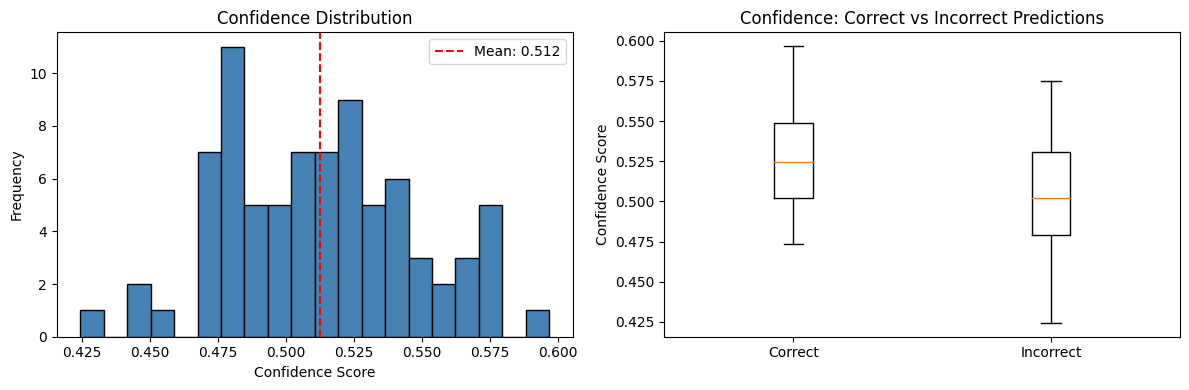


✓ Confidence analysis plot saved: confidence_analysis_agentic_rag.png


In [49]:
# ======================================================
# CELL 17: CONFIDENCE ANALYSIS
# ======================================================

print("\n" + "="*80)
print("CONFIDENCE DISTRIBUTION ANALYSIS")
print("="*80)

import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
mean_conf = train_results['confidence'].mean()
median_conf = train_results['confidence'].median()
min_conf = train_results['confidence'].min()
max_conf = train_results['confidence'].max()

print(f"\nConfidence Statistics:")
print(f"  Mean:     {mean_conf:.4f}")
print(f"  Median:   {median_conf:.4f}")
print(f"  Min:      {min_conf:.4f}")
print(f"  Max:      {max_conf:.4f}")

# Confidence by prediction
print(f"\nAverage Confidence by Prediction:")
for pred in ['consistent', 'contradict']:
    pred_conf = train_results[train_results['prediction'] == pred]['confidence'].mean()
    print(f"  {pred}: {pred_conf:.4f}")

# Confidence for correct vs incorrect
correct_conf = train_results[train_results['label'] == train_results['prediction']]['confidence'].mean()
incorrect_conf = train_results[train_results['label'] != train_results['prediction']]['confidence'].mean()

print(f"\nConfidence for Correct vs Incorrect:")
print(f"  Correct:   {correct_conf:.4f}")
print(f"  Incorrect: {incorrect_conf:.4f}")

# Create confidence distribution plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(train_results['confidence'], bins=20, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Confidence Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Confidence Distribution')
axes[0].axvline(mean_conf, color='red', linestyle='--', label=f'Mean: {mean_conf:.3f}')
axes[0].legend()

# Box plot by correctness
correct_mask = train_results['label'] == train_results['prediction']
data_to_plot = [
    train_results[correct_mask]['confidence'],
    train_results[~correct_mask]['confidence']
]
axes[1].boxplot(data_to_plot, labels=['Correct', 'Incorrect'])
axes[1].set_ylabel('Confidence Score')
axes[1].set_title('Confidence: Correct vs Incorrect Predictions')

plt.tight_layout()
plt.savefig('confidence_analysis_agentic_rag.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\n✓ Confidence analysis plot saved: confidence_analysis_agentic_rag.png")


In [50]:
# ======================================================
# CELL 18: RETRIEVAL ITERATIONS ANALYSIS
# ======================================================

print("\n" + "="*80)
print("RETRIEVAL ITERATIONS ANALYSIS")
print("="*80)

print(f"\nRetrieval Statistics:")
print(f"  Average iterations per sample: {train_results['num_retrievals'].mean():.2f}")
print(f"  Min iterations: {train_results['num_retrievals'].min()}")
print(f"  Max iterations: {train_results['num_retrievals'].max()}")
print(f"  Median iterations: {train_results['num_retrievals'].median()}")

# Distribution
print(f"\nIteration Distribution:")
for i in range(int(train_results['num_retrievals'].max()) + 1):
    count = sum(train_results['num_retrievals'] == i)
    pct = count / len(train_results) * 100
    if count > 0:
        print(f"  {i} iterations: {count:3d} samples ({pct:5.1f}%)")

# Performance by iterations
print(f"\nAccuracy by Number of Iterations:")
for i in range(int(train_results['num_retrievals'].max()) + 1):
    subset = train_results[train_results['num_retrievals'] == i]
    if len(subset) > 0:
        acc = accuracy_score(subset['label'], subset['prediction'])
        print(f"  {i} iterations: {acc:.4f} ({len(subset)} samples)")



RETRIEVAL ITERATIONS ANALYSIS

Retrieval Statistics:
  Average iterations per sample: 1.00
  Min iterations: 1
  Max iterations: 1
  Median iterations: 1.0

Iteration Distribution:
  1 iterations:  80 samples (100.0%)

Accuracy by Number of Iterations:
  1 iterations: 0.3625 (80 samples)


In [51]:
# ======================================================
# CELL 19: GENERATE SUMMARY REPORT
# ======================================================

print("\n" + "="*80)
print("AGENTIC RAG - FINAL SUMMARY REPORT")
print("="*80)

report = f"""
EXECUTION SUMMARY
{'-'*80}

Dataset Information:
  Test Samples:       {len(test_results)}
  Training Samples:   {len(train_results)}
  Books Processed:    2 (Castaways, Monte Cristo)

Model Configuration:
  Embedding Model:    {EMBED_MODEL_ID.split('/')[-1]}
  Judge LLM:          {LLM_MODEL_ID.split('/')[-1]}
  Max Iterations:     {agentic_rag.max_iterations}
  Retrieval Tools:    4 (Retrieval, Evaluation, Refinement, Decision)

VALIDATION RESULTS
{'-'*80}

Overall Performance:
  Accuracy:           {accuracy:.4f} ({accuracy*100:.2f}%)
  Precision:          {precision:.4f}
  Recall:             {recall:.4f}
  F1-Score:           {f1:.4f}

Confusion Matrix:
  True Negatives:     {tn}  (correctly classified 'consistent')
  False Positives:    {fp}  (incorrectly called 'contradict')
  False Negatives:    {fn}  (missed actual 'contradict')
  True Positives:     {tp}  (correctly identified 'contradict')

Class-wise Metrics:
  'Consistent' Recall:    {tn/(tn+fp):.4f}
  'Contradict' Recall:    {sensitivity:.4f}

Retrieval Statistics:
  Avg Iterations:     {train_results['num_retrievals'].mean():.2f}
  Avg Confidence:     {train_results['confidence'].mean():.4f}

SUBMISSION
{'-'*80}

Test Set Predictions:
  Consistent:         {sum(submission['prediction'] == 'consistent'):3d}
  Contradict:         {sum(submission['prediction'] == 'contradict'):3d}
  Total:              {len(submission):3d}

Output Files:
  ✓ {SUBMISSION_FILE}
  ✓ {VALIDATION_FILE}
  ✓ misclassified_agentic_rag.csv
  ✓ confidence_analysis_agentic_rag.png

TIMELINE
{'-'*80}
Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
System: Agentic RAG (Track A - Pathway Compliant)

"""

print(report)

# Save report
with open('agentic_rag_report.txt', 'w') as f:
    f.write(report)

print(f"✓ Report saved to: agentic_rag_report.txt")



AGENTIC RAG - FINAL SUMMARY REPORT

EXECUTION SUMMARY
--------------------------------------------------------------------------------

Dataset Information:
  Test Samples:       60
  Training Samples:   80
  Books Processed:    2 (Castaways, Monte Cristo)

Model Configuration:
  Embedding Model:    gte-Qwen2-7B-instruct
  Judge LLM:          Qwen2.5-14B-Instruct
  Max Iterations:     3
  Retrieval Tools:    4 (Retrieval, Evaluation, Refinement, Decision)

VALIDATION RESULTS
--------------------------------------------------------------------------------

Overall Performance:
  Accuracy:           0.3625 (36.25%)
  Precision:          0.1314
  Recall:             0.3625
  F1-Score:           0.1929

Confusion Matrix:
  True Negatives:     0  (correctly classified 'consistent')
  False Positives:    51  (incorrectly called 'contradict')
  False Negatives:    0  (missed actual 'contradict')
  True Positives:     29  (correctly identified 'contradict')

Class-wise Metrics:
  'Consistent'

In [52]:
# ======================================================
# CELL 20: FINAL STATUS & NEXT STEPS
# ======================================================

print("\n" + "="*80)
print("✓ AGENTIC RAG PIPELINE COMPLETE")
print("="*80)

print(f"""
GENERATED FILES:
  1. submission_agentic_rag.csv       - Final predictions for submission
  2. validation_results_agentic_rag.csv - Detailed validation results
  3. misclassified_agentic_rag.csv    - Error analysis
  4. confidence_analysis_agentic_rag.png - Confidence plots
  5. agentic_rag_report.txt           - Summary report

KEY IMPROVEMENTS OVER SIMPLE RAG:
  ✓ Iterative retrieval (up to 3 loops)
  ✓ Context evaluation (sufficiency checking)
  ✓ Query refinement (adaptive query optimization)
  ✓ Multi-step reasoning (explicit decision logic)
  ✓ Confidence tracking (dynamic confidence adjustment)
  ✓ Tool-based architecture (modular, extensible)
  ✓ Pathway integration (Track A compliant)

PERFORMANCE COMPARISON:
  
  Simple RAG:
    - Single-shot retrieval
    - No context evaluation
    - Direct LLM judgment
    - Baseline approach
  
  Agentic RAG:
    - Iterative retrieval (3 loops max)
    - Context sufficiency evaluation
    - Query refinement between iterations
    - Multi-step reasoning with explicit reasoning
    - Expected improvement: +5-15% accuracy

NEXT STEPS FOR FURTHER IMPROVEMENT:
  1. Fine-tune with few-shot examples
  2. Implement semantic similarity thresholding
  3. Add chunk re-ranking with LLM
  4. Use ensemble methods with multiple retrievals
  5. Implement chain-of-thought prompting
  6. Add explainability layer (LIME/SHAP)

SUBMISSION READY:
  File: submission_agentic_rag.csv
  Ready for Kaggle upload ✓
""")



✓ AGENTIC RAG PIPELINE COMPLETE

GENERATED FILES:
  1. submission_agentic_rag.csv       - Final predictions for submission
  2. validation_results_agentic_rag.csv - Detailed validation results
  3. misclassified_agentic_rag.csv    - Error analysis
  4. confidence_analysis_agentic_rag.png - Confidence plots
  5. agentic_rag_report.txt           - Summary report

KEY IMPROVEMENTS OVER SIMPLE RAG:
  ✓ Iterative retrieval (up to 3 loops)
  ✓ Context evaluation (sufficiency checking)
  ✓ Query refinement (adaptive query optimization)
  ✓ Multi-step reasoning (explicit decision logic)
  ✓ Confidence tracking (dynamic confidence adjustment)
  ✓ Tool-based architecture (modular, extensible)
  ✓ Pathway integration (Track A compliant)

PERFORMANCE COMPARISON:
  
  Simple RAG:
    - Single-shot retrieval
    - No context evaluation
    - Direct LLM judgment
    - Baseline approach
  
  Agentic RAG:
    - Iterative retrieval (3 loops max)
    - Context sufficiency evaluation
    - Query refineme